# Stress Testing — Code Companion

This notebook computes all statistics documented in the accompanying reference files:

- **Methodology:** `documentation/Stress_methodology.md` — scenario construction, formulas, and interpretation
- **Results:** `documentation/Stress_results.md` — all numerical outputs, findings, and risk actions

**Sections**
1. Setup
2. Scenario Library
3. Portfolio Stress Results
4. Instrument-Level Attribution
5. Asset Class Decomposition
6. Stress P&L vs Statistical Risk
7. Scenario Correlation

## 1. Setup

In [18]:
from utils import setup_repo_root

repo_root = setup_repo_root()
print('Working directory:', repo_root)

Working directory: /home/martin/python/risk-assessment


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

from data_loader import (
    clean_prices,
    load_positions,
    load_prices,
    load_scenarios,
)
from risk_metrics import (
    compute_cvar_historical,
    compute_var_historical,
    compute_var_parametric,
)
from stress import (
    apply_scenarios,
    instrument_stress_attribution,
    subclass_stress_breakdown,
)

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 4)})
pd.set_option('display.float_format', '{:.6f}'.format)

PORTFOLIO_NAV = 500_000_000  # CHF 500 M

In [3]:
positions  = load_positions()
scenarios  = load_scenarios()
prices_raw = load_prices()
prices_clean = clean_prices(prices_raw)

prices_wide = (
    prices_clean
    .pivot(index='date', columns='instrument_id', values='price')
    .sort_index()
)
returns = prices_wide.pct_change().dropna(how='all')

weights = positions.set_index('instrument_id')['weight']
common  = returns.columns.intersection(weights.index)
port_returns = returns[common].dot(weights[common])

print(f'Portfolio NAV:           CHF {PORTFOLIO_NAV/1e6:.0f} M')
print(f'Instruments in portfolio: {len(positions)}')
print(f'Scenarios available:      {scenarios["scenario_id"].nunique()}')
print(f'Return series:            {len(port_returns)} days  '
      f'({port_returns.index.min().date()} → {port_returns.index.max().date()})')

Portfolio NAV:           CHF 500 M
Instruments in portfolio: 18
Scenarios available:      3
Return series:            252 days  (2025-04-01 → 2026-03-18)


## 2. Scenario Library
*Methodology: `Stress_methodology.md` section 3 · Results: `Stress_results.md` section 1*

In [17]:
descs = (
    scenarios[['scenario_id', 'scenario_name', 'description']]
    .drop_duplicates('scenario_id')
    .set_index('scenario_id')
)
for _, row in descs.iterrows():
    print(row['scenario_name'])
    print(f"  {row['description']}", end="\n\n")

shock_pivot = (
    scenarios
    .pivot(index='instrument_id', columns='scenario_name', values='shock_return')
    .merge(positions[['instrument_id', 'sub_class', 'weight']], on='instrument_id')
    .sort_values(['sub_class', 'instrument_id'])
    .set_index('instrument_id')
)
scenario_cols = [c for c in shock_pivot.columns if c not in ('sub_class', 'weight')]

display(
    shock_pivot.style
    .format({
        **{col: '{:+.1%}' for col in scenario_cols},
        'weight': '{:.1%}',
    })
    .background_gradient(cmap='RdYlGn', subset=scenario_cols, vmin=-0.25, vmax=0.10)
    .set_caption('Scenario shock returns by instrument (green = gain, red = loss)')
)

SNB Emergency Rate Hike (+100bp)
  The SNB raises rates by 100bp unexpectedly to defend the CHF amid inflation concerns. Bond prices fall via duration; equities decline with financials and insurance hit hardest.

European Sovereign Debt Stress
  A French fiscal crisis triggers spread widening across European sovereigns. Flight to quality into Swiss government bonds. Corporate credit and European equities sell off sharply.

Global Equity Market Crash
  A sudden global equity sell-off of ~20%, led by technology stocks. Flight to quality supports government bonds. Corporate credit spreads widen moderately.



,European Sovereign Debt Stress,Global Equity Market Crash,SNB Emergency Rate Hike (+100bp),sub_class,weight
instrument_id,,,,,
NESN_CORP,-3.0%,-2.0%,-4.6%,CHF_CORP,6.0%
NOVN_CORP,-3.5%,-2.5%,-6.1%,CHF_CORP,5.0%
UBSG_CORP,-5.0%,-4.0%,-6.3%,CHF_CORP,4.0%
CHGOV_10Y,+4.0%,+5.0%,-8.7%,CHF_GOVT,10.0%
CHGOV_2Y,+0.5%,+1.0%,-1.9%,CHF_GOVT,15.0%
CHGOV_5Y,+2.0%,+3.0%,-4.6%,CHF_GOVT,12.0%
ALV_GR,-12.0%,-20.0%,-8.0%,EUR_EQUITY,2.0%
ASML_NA,-8.0%,-25.0%,-7.0%,EUR_EQUITY,2.5%
SAN_FP,-10.0%,-15.0%,-3.0%,EUR_EQUITY,3.0%


## 3. Portfolio Stress Results
*Methodology: `Stress_methodology.md` section 4 · Results: `Stress_results.md` section 2*

In [ ]:
results = apply_scenarios(positions, scenarios).sort_values('portfolio_return')
results['pnl_chf_m'] = results['pnl_chf'] / 1e6

print(f"{'Scenario':<40} {'Return':>8}  {'P&L (CHF M)':>12}")
print('-' * 62)
for _, row in results.iterrows():
    print(f"{row['scenario_name']:<40} {row['portfolio_return']:>8.2%}  "
          f"CHF {row['pnl_chf_m']:>+8.1f} M")

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(results['scenario_name'], results['portfolio_return'] * 100,
        color='steelblue', edgecolor='white')
ax.axvline(0, color='black', linewidth=0.7)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.0f} %'))
ax.set_xlabel('Portfolio return (%)')
ax.set_title('Portfolio P&L by Stress Scenario')
plt.tight_layout()
plt.show()

## 4. Instrument-Level Attribution
*Methodology: `Stress_methodology.md` section 4 · Results: `Stress_results.md` section 3*

In [ ]:
attr = instrument_stress_attribution(positions, scenarios)
attr['contribution_bps'] = attr['weighted_return'] * 10_000

contrib_pivot = (
    attr
    .pivot(index='instrument_id', columns='scenario_name', values='contribution_bps')
    .merge(positions[['instrument_id', 'sub_class', 'weight']], on='instrument_id')
    .sort_values(['sub_class', 'instrument_id'])
    .set_index('instrument_id')
)
scenario_cols = [c for c in contrib_pivot.columns if c not in ('sub_class', 'weight')]

display(
    contrib_pivot.style
    .format({
        **{c: '{:+.1f} bps' for c in scenario_cols},
        'weight': '{:.1%}',
    })
    .background_gradient(cmap='RdYlGn', subset=scenario_cols, vmin=-150, vmax=80)
    .set_caption('Instrument contribution to portfolio return per scenario (bps)')
)

worst_scenario = results.iloc[0]['scenario_name']
worst_attr = (
    attr[attr['scenario_name'] == worst_scenario]
    .assign(contribution_bps=lambda d: d['weighted_return'] * 10_000)
    .sort_values('contribution_bps')
)

print(f"\nWorst scenario: {worst_scenario}")
print(f"{'Instrument':<15} {'Sub-class':<15} {'Shock':>8}  {'Contribution':>14}  {'P&L (CHF M)':>12}")
print('-' * 70)
for _, row in worst_attr.iterrows():
    print(f"{row['instrument_id']:<15} {row['sub_class']:<15} "
          f"{row['shock_return']:>8.1%}  "
          f"{row['contribution_bps']:>+11.1f} bps  "
          f"CHF {row['pnl_chf']/1e6:>+7.1f} M")

## 5. Asset Class Decomposition
*Methodology: `Stress_methodology.md` section 4 · Results: `Stress_results.md` section 4*

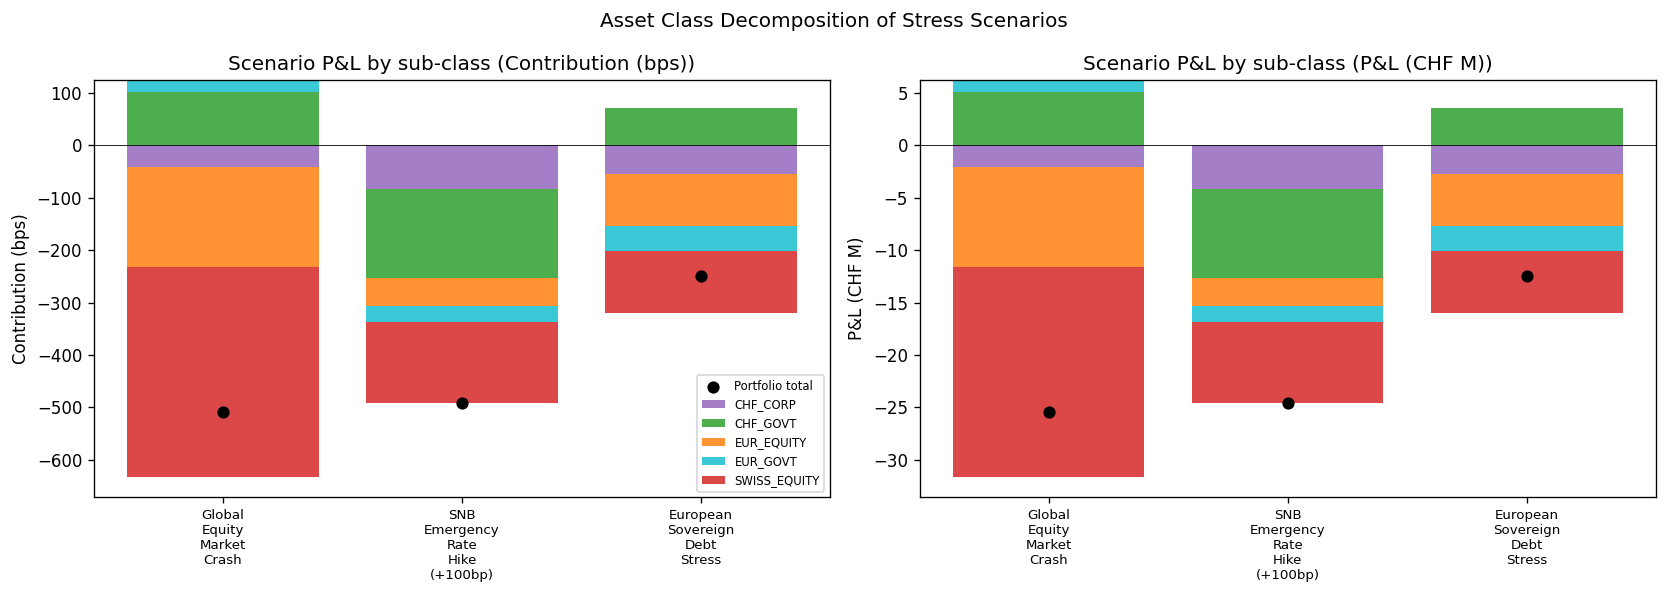


Sub-class         Global Equity Market  SNB Emergency Rate H  European Sovereign D
----------------------------------------------------------------------------------
CHF_CORP                        -40.5 bps                -83.3 bps                -55.5 bps
CHF_GOVT                       +101.0 bps               -170.7 bps                +71.5 bps
EUR_EQUITY                     -192.5 bps                -52.5 bps                -99.0 bps
EUR_GOVT                        +23.5 bps                -30.9 bps                -48.0 bps
SWISS_EQUITY                   -400.5 bps               -153.5 bps               -118.0 bps
----------------------------------------------------------------------------------
TOTAL                          -509.0 bps               -490.9 bps               -249.0 bps


In [7]:
sub_df = subclass_stress_breakdown(positions, scenarios)
sub_df['contribution_bps'] = sub_df['weighted_return'] * 10_000
sub_df['pnl_chf_m'] = sub_df['pnl_chf'] / 1e6

# Stacked bar: one group per scenario, stacked by sub_class
scenario_order = results['scenario_name'].tolist()  # worst first
sub_classes = sorted(sub_df['sub_class'].unique())
SUB_COLOURS = {
    'SWISS_EQUITY': '#d62728',
    'EUR_EQUITY':   '#ff7f0e',
    'CHF_CORP':     '#9467bd',
    'CHF_GOVT':     '#2ca02c',
    'EUR_GOVT':     '#17becf',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label, fmt in [
    (axes[0], 'contribution_bps', 'Contribution (bps)', '{:.0f} bps'),
    (axes[1], 'pnl_chf_m',        'P&L (CHF M)',        'CHF {:.1f} M'),
]:
    bottoms_pos = np.zeros(len(scenario_order))
    bottoms_neg = np.zeros(len(scenario_order))
    x = np.arange(len(scenario_order))

    for sc in sub_classes:
        vals = np.array([
            sub_df.loc[
                (sub_df['scenario_name'] == sn) & (sub_df['sub_class'] == sc),
                metric
            ].sum() for sn in scenario_order
        ])
        pos_vals = np.where(vals >= 0, vals, 0)
        neg_vals = np.where(vals <  0, vals, 0)
        ax.bar(x, pos_vals, bottom=bottoms_pos,
               color=SUB_COLOURS.get(sc, 'grey'), label=sc, alpha=0.85)
        ax.bar(x, neg_vals, bottom=bottoms_neg,
               color=SUB_COLOURS.get(sc, 'grey'), alpha=0.85)
        bottoms_pos += pos_vals
        bottoms_neg += neg_vals

    # Total return markers
    totals = [sub_df[sub_df['scenario_name'] == sn][metric].sum() for sn in scenario_order]
    ax.scatter(x, totals, color='black', zorder=5, s=40, label='Portfolio total')

    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [sn.replace(' ', '\n') for sn in scenario_order],
        fontsize=8
    )
    ax.set_ylabel(label)
    ax.set_title(f'Scenario P&L by sub-class ({label})')

axes[0].legend(fontsize=7, loc='lower right')
plt.suptitle('Asset Class Decomposition of Stress Scenarios', fontsize=12)
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Sub-class':<16}", end='')
for sn in scenario_order:
    print(f"  {sn[:20]:>20}", end='')
print()
print('-' * (16 + 22 * len(scenario_order)))
for sc in sub_classes:
    print(f"{sc:<16}", end='')
    for sn in scenario_order:
        val = sub_df.loc[
            (sub_df['scenario_name'] == sn) & (sub_df['sub_class'] == sc),
            'contribution_bps'
        ].sum()
        print(f"  {val:>+19.1f} bps", end='')
    print()
print('-' * (16 + 22 * len(scenario_order)))
print(f"{'TOTAL':<16}", end='')
for sn in scenario_order:
    val = sub_df.loc[sub_df['scenario_name'] == sn, 'contribution_bps'].sum()
    print(f"  {val:>+19.1f} bps", end='')
print()

## 6. Stress P&L vs Statistical Risk
*Methodology: `Stress_methodology.md` section 5 · Results: `Stress_results.md` section 5*

Statistical risk benchmarks (full-sample)
  VaR 99% 1-day  (historical):  2.0153%   CHF 10.1 M
  VaR 99% 1-day  (parametric):  1.4741%   CHF 7.4 M
  ES  99% 1-day  (historical):  2.3921%   CHF 12.0 M
  VaR 99% 10-day (√10 scaled):  6.3730%   CHF 31.9 M

Scenario                                    Loss   × VaR 1d   × ES 1d   × VaR 10d
--------------------------------------------------------------------------------
Global Equity Market Crash                 5.09%       2.5×      2.1×        0.8×
SNB Emergency Rate Hike (+100bp)           4.91%       2.4×      2.1×        0.8×
European Sovereign Debt Stress             2.49%       1.2×      1.0×        0.4×


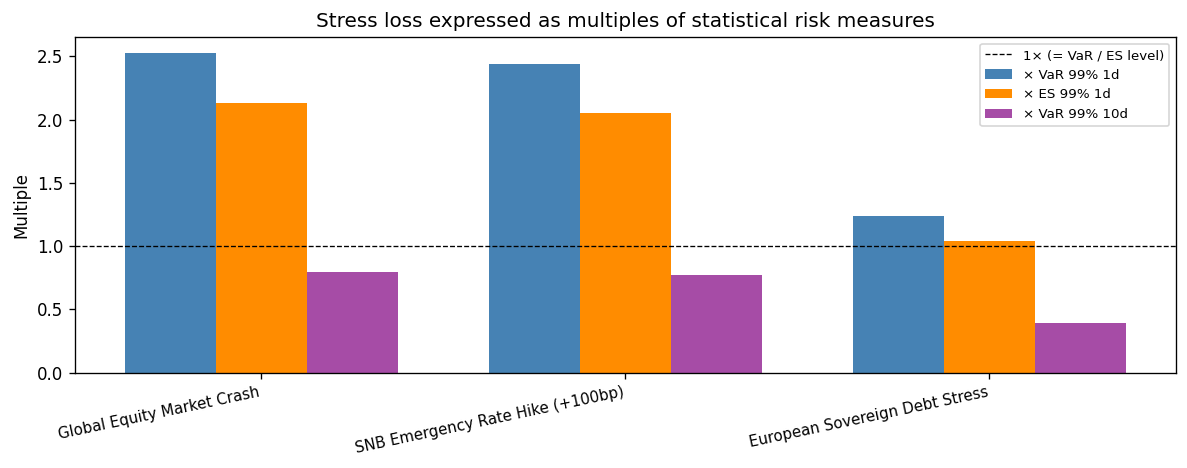

In [8]:
var_1d_hist  = compute_var_historical(port_returns, confidence=0.99)
var_1d_param = compute_var_parametric(port_returns, confidence=0.99)
es_1d_hist   = compute_cvar_historical(port_returns, confidence=0.99)
var_10d      = var_1d_hist * (10 ** 0.5)

print('Statistical risk benchmarks (full-sample)')
print(f'  VaR 99% 1-day  (historical):  {var_1d_hist:.4%}   CHF {var_1d_hist*PORTFOLIO_NAV/1e6:.1f} M')
print(f'  VaR 99% 1-day  (parametric):  {var_1d_param:.4%}   CHF {var_1d_param*PORTFOLIO_NAV/1e6:.1f} M')
print(f'  ES  99% 1-day  (historical):  {es_1d_hist:.4%}   CHF {es_1d_hist*PORTFOLIO_NAV/1e6:.1f} M')
print(f'  VaR 99% 10-day (√10 scaled):  {var_10d:.4%}   CHF {var_10d*PORTFOLIO_NAV/1e6:.1f} M')
print()

var_multiples = results.copy()
var_multiples['loss_pct']    = -var_multiples['portfolio_return']
var_multiples['var1d_mult']  = var_multiples['loss_pct'] / var_1d_hist
var_multiples['var10d_mult'] = var_multiples['loss_pct'] / var_10d
var_multiples['es1d_mult']   = var_multiples['loss_pct'] / es_1d_hist

print(f"{'Scenario':<40} {'Loss':>7}  {'× VaR 1d':>9}  {'× ES 1d':>8}  {'× VaR 10d':>10}")
print('-' * 80)
for _, row in var_multiples.iterrows():
    print(f"{row['scenario_name']:<40} {row['loss_pct']:>7.2%}  "
          f"{row['var1d_mult']:>8.1f}×  "
          f"{row['es1d_mult']:>7.1f}×  "
          f"{row['var10d_mult']:>9.1f}×")

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(var_multiples))
w = 0.25
ax.bar(x - w,   var_multiples['var1d_mult'],  w, label='× VaR 99% 1d',  color='steelblue')
ax.bar(x,        var_multiples['es1d_mult'],   w, label='× ES 99% 1d',   color='darkorange')
ax.bar(x + w,   var_multiples['var10d_mult'], w, label='× VaR 99% 10d', color='purple', alpha=0.7)
ax.axhline(1, color='black', linewidth=0.8, linestyle='--', label='1× (= VaR / ES level)')
ax.set_xticks(x)
ax.set_xticklabels(var_multiples['scenario_name'], rotation=12, ha='right', fontsize=9)
ax.set_ylabel('Multiple')
ax.set_title('Stress loss expressed as multiples of statistical risk measures')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Scenario Correlation & Risk Factor Coverage
*Methodology: `Stress_methodology.md` section 7 · Results: `Stress_results.md` section 7*

In [ ]:
SCEN_COLOURS = ['steelblue', 'darkorange', 'purple']

# Shock matrix: rows = instruments, columns = scenarios
shock_matrix = scenarios.pivot(
    index='instrument_id', columns='scenario_name', values='shock_return'
).dropna()

corr = shock_matrix.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: correlation heatmap
ax = axes[0]
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='black' if abs(corr.values[i, j]) < 0.7 else 'white')
ax.set_title('Scenario shock correlation matrix')

# Right: shock magnitude by sub-class per scenario
ax2 = axes[1]
shock_w_sub = shock_matrix.merge(
    positions[['instrument_id', 'sub_class']].set_index('instrument_id'),
    left_index=True, right_index=True
)
sub_mean = shock_w_sub.groupby('sub_class')[shock_matrix.columns.tolist()].mean()
x = np.arange(len(sub_mean))
w = 0.25
for i, (sn, col) in enumerate(zip(shock_matrix.columns, SCEN_COLOURS)):
    ax2.bar(x + (i - 1) * w, sub_mean[sn] * 100, w,
            color=col, label=sn, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(sub_mean.index, rotation=20, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.0f} %'))
ax2.set_ylabel('Mean shock return (%)')
ax2.set_title('Average sub-class shock by scenario')
ax2.legend(fontsize=7)

plt.suptitle('Scenario Correlation & Risk Factor Coverage', fontsize=12)
plt.tight_layout()
plt.show()

print('Pairwise scenario correlations:')
for i, sn_i in enumerate(corr.columns):
    for j, sn_j in enumerate(corr.columns):
        if j > i:
            print(f'  {sn_i} vs {sn_j}: {corr.loc[sn_i, sn_j]:.4f}')